In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import binary_dilation

from plotscripts import getimagedata, subtract
from module import import_ab


In [2]:
# Parameters
n    = 1000
FoV  = 40 # uas
pixel_scale = FoV / n  

In [3]:
#get critical curve 
alpha1, beta1 = import_ab(1.01, 60, True) 

# critical curve in r, phi
R = np.sqrt(alpha1**2 + beta1**2)
PHI = np.arctan2(beta1, alpha1) 
alpha = np.round((alpha1 / pixel_scale + 0.5) * n).astype(int)
beta = np.round((beta1 / pixel_scale + 0.5) * n).astype(int)

def f(phi):
    print(f'In shape {phi.shape}')
    R_ref = np.sqrt(alpha1**2 + beta1**2)
    
    phi       = np.mod(phi + np.pi, 2*np.pi) - np.pi
    PHI_ref   = np.mod(PHI + np.pi, 2*np.pi) - np.pi

    inds=[]
    for p in phi:
        dPHI = np.abs(PHI_ref - p)
        ind = np.nanargmin(dPHI) 
        inds.append(ind)
     
    inds = np.array(inds)
   
    phi_new = PHI_ref[inds]
    r_new = R_ref[inds]
    
    print(f'Out PHI shape {phi_new.shape}')
    print(f'Out R shape {r_new.shape}')

    return r_new, phi_new

#test function f
# phi_test = np.linspace(-np.pi,np.pi,30)
# r,_ = f(phi_test)
# plt.plot(r)
# # plt.plot(alpha1, beta1)

In [4]:
# Grid generation

a    = FoV * ((np.arange(n) + 0.5) / n - 0.5)
b    = FoV * ((np.arange(n) + 0.5) / n - 0.5)
A, B = np.meshgrid(a, b)

In [5]:
img_path = "cache/Ma101_w1/Rh1_i60"
_, _, _, Img = subtract(img_path+"/n100", img_path+"/n0", 999 , ave=False)
# data_id_all, min, max, Img = getimagedata(img_path+'/n0', 1000)


read from cache/Ma101_w1/Rh1_i60/n100 and cache/Ma101_w1/Rh1_i60/n0
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n0/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_1000.h5
8


(-8.0, 8.0)

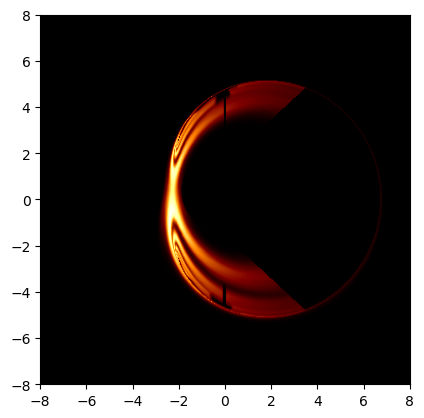

In [6]:
plt.imshow((Img/np.max(Img))**0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
plt.xlim(-8,8)
plt.ylim(-8,8)

In [7]:
xmin, xmax = 400, 700
ymin, ymax = 300, 700

Img_c  = Img[ymin:ymax, xmin:xmax]
A_c    = A[ymin:ymax, xmin:xmax]
B_c    = B[ymin:ymax, xmin:xmax]

In [8]:
# pick only inside of curve, and spesify distance from the curve
r_pix = np.sqrt(( A_c**2 + B_c**2 ))
phi_pix = np.arctan2(B_c,A_c)

phi_flat = phi_pix.ravel()
r_out, phi_out = f(phi_flat)

r_crit = r_out.reshape(phi_pix.shape)
phi_crit = phi_out.reshape(phi_pix.shape)

In shape (120000,)
Out PHI shape (120000,)
Out R shape (120000,)


In [9]:
#mask r
r_mask = (r_pix > 0.75 * r_crit) & (r_pix < 0.99 * r_crit)

#mask phi 
phi_c = np.pi/2
phi_mask =  (np.abs(phi_pix) > 0.94*phi_c ) & (np.abs(phi_pix) < 1.13*phi_c )

mask_good = (Img_c > 0.5e16)
mask_bad  = (~mask_good) & r_mask & phi_mask

In [10]:
i_good, j_good = np.nonzero(mask_good)
Img_good = Img_c[(i_good, j_good)]
print(Img_good.shape)

(9886,)


In [11]:
phi_good = np.arctan2(b[i_good], a[j_good])  # double check convention
r_good   = np.sqrt(( a[j_good] * a[j_good] + b[i_good] * b[i_good] ))/f(phi_good)

In shape (9886,)
Out PHI shape (9886,)
Out R shape (9886,)


In [12]:
i_bad,  j_bad  = np.nonzero(mask_bad)
Img_bad = Img_c[(i_bad, j_bad)]

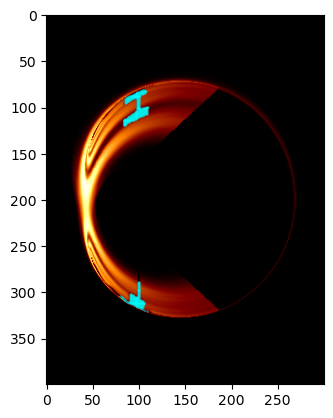

In [13]:
plt.scatter(j_bad,i_bad, s=0.1, color='cyan')
plt.imshow(Img_c**0.4, cmap='afmhot')

In [72]:
#expand boundary 
dilated_bad  = binary_dilation(mask_bad, structure=np.ones((5, 5)))
edge_mask = dilated_bad & ~mask_bad
adjacent_values = Img_c[edge_mask]
i_edge, j_edge = np.nonzero(edge_mask)

coords_bad = np.column_stack((i_bad, j_bad))
coords_edge = np.column_stack((i_edge, j_edge))
coords_combined = np.vstack([coords_bad, coords_edge])
coords_unique = np.unique(coords_combined, axis=0)

i_bad, j_bad = coords_unique[:, 0], coords_unique[:, 1]

Img_bad = Img_c[i_bad, j_bad]
print(i_bad.shape, j_bad.shape)

(1274,) (1274,)


In [73]:
phi_bad = np.arctan2(b[i_bad], a[j_bad])  # double check convention
r_bad   = np.sqrt(( a[j_bad] * a[j_bad] + b[i_bad] * b[i_bad] )) / f(phi_bad)

In shape (1274,)
Out PHI shape (1274,)
Out R shape (1274,)


In [74]:
Img_fill = scipy.interpolate.griddata((r_good, phi_good), Img_good, (r_bad, phi_bad), fill_value=0.0, method='linear')

ValueError: Input points array must have 2 dimensions.

In [59]:
Img_fixed = Img_c.copy()
Img_fixed[(i_bad, j_bad)] = Img_fill

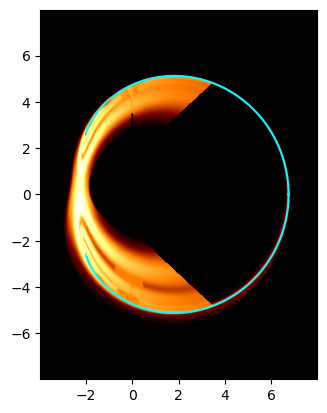

In [63]:

alpha_min = FoV * ((xmin + 0.5) / n - 0.5)
alpha_max = FoV * ((xmax - 0.5) / n - 0.5)
beta_min  = FoV * ((ymin + 0.5) / n - 0.5)
beta_max  = FoV * ((ymax - 0.5) / n - 0.5)
extent=[alpha_min, alpha_max, beta_min, beta_max]


plt.imshow(Img_fixed**0.2, cmap='afmhot', origin='lower', extent=extent)
# plt.scatter(0,-4, s=30, color='blue')
plt.plot(alpha1, beta1, color='cyan', linewidth=1.5, label='Critical Curve')
# plt.xlim(-6,6)
# plt.ylim(-6,6)
# plt.plot(alpha, beta, linewidth=1, color='deepskyblue', linestyle='-')
plt.savefig('output/testinterpolation.png')

# Try RBFInterpolator

In [53]:
X = np.column_stack((r_good, phi_good))  
Y = Img_good                             
X_new = np.column_stack((r_bad, phi_bad)) 


In [55]:
from scipy.interpolate import RBFInterpolator

rbf = RBFInterpolator(X, Y, kernel='thin_plate_spline', neighbors=10)
Img_fill = rbf(X_new)


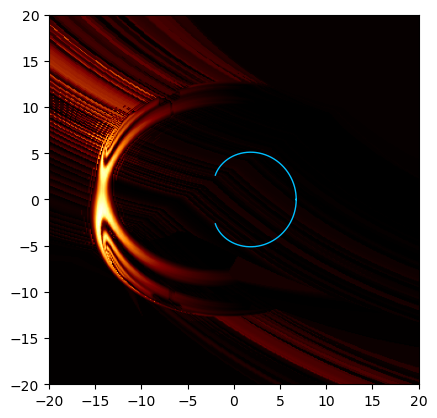

In [56]:
plt.imshow(Img_fixed**0.5, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
# plt.scatter(0,-4, s=30, color='blue')
# plt.xlim(-6,6)
# plt.ylim(-6,6)
plt.plot(alpha1, beta1, linewidth=1, color='deepskyblue', linestyle='-')
# plt.savefig('output/testinterpolation.png')